# 코드 기반 암호 강의 노트북 — Classic McEliece (축소판)
## Code-based Cryptography: McEliece with Hamming(7,4)

---

이 노트북은 **코드 기반 암호를 처음 배우는 사람**, 특히 수학이 낯선 분을 위한 강의 자료입니다.

코드 기반 암호를 한 문장으로 요약하면 이렇습니다.

> **"편지에 일부러 오타를 잔뜩 섞어 보내고, 오타 교정 비법을 아는 사람만 원문을 읽는 방식"**

여기서 "오타 교정 비법"에 해당하는 것이 **오류정정 코드**(전송 중 깨진 비트를 스스로 찾아
고치는 기술 — CD, USB, 위성 통신에서 실제로 쓰입니다)입니다. 이 노트북에서는
이론 → 직접 구현 → 반복 검증 → 그림으로 확인 순서로,
**"일부러 넣은 오류를 비밀키를 가진 사람만 고칠 수 있다"**는 핵심을 눈으로 확인합니다.

> 이 노트북은 통합본 `양자내성암호_입문자용_v3.ipynb`에서 코드 기반(McEliece) 주제를
> 분리·정리한 강의 자료입니다. 실행 셀과 출력은 원본 그대로이며,
> 재실행하려면 **0장(Setup) 셀을 먼저 실행**해야 합니다.

### 학습 목표
1. 오류정정 코드(Hamming(7,4) — 4비트 정보를 7비트로 늘려 보내 1비트 오류를 스스로 고치는 가장 작은 교정 코드)가 오류를 어떻게 찾아 고치는지 이해합니다.
2. 공개키를 만드는 "뒤섞기" 구조($G' = SGP$)가 왜 "누구나 잠글 수 있지만 한 사람만 열 수 있는" 비대칭을 만드는지 감을 잡습니다.
3. McEliece 축소판의 키 생성·암호화·복호를 파이썬 코드로 직접 돌려 봅니다.
4. 2,000번 반복 실험으로 복호 성공률을 확인하고, 비트 그림으로 교정 과정을 관찰합니다.
5. Classic McEliece와 HQC가 표준화에서 어떤 위치(백업 후보)에 있는지 파악합니다.

> **선행 지식**: 특별한 수학 지식은 필요 없습니다. "0과 1로 이루어진 목록을 규칙에 따라
> 섞는다" 정도의 감각과, 공개키 암호의 기본 개념(자물쇠는 공개, 열쇠는 비밀)만 있으면 충분합니다.
> 행렬 곱셈이 기억나지 않아도 본문의 비유 설명으로 따라올 수 있습니다.

## 0. 준비 (Setup)

아래 공통 설정 셀(Harness)은 통합본 전체에서 공유하는 준비 코드입니다.
실험 결과가 매번 같게 나오도록 난수의 출발점을 고정하고(`RNG`),
그래프의 한글이 깨지지 않게 폰트를 설정하며, 크기·시간 측정 도우미(`nbytes`, `timeit`)와
실험 결과 기록장(`log_metric`)을 정의합니다. **이 셀을 먼저 실행해야 이후 셀이 동작합니다.**

In [1]:
import time, hashlib, secrets, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd, log2, floor, pi, sqrt

RNG = np.random.default_rng(20260722)   # 재현성 시드
plt.rcParams['figure.dpi'] = 110

# --- 한글 폰트 자동 설정 (그래프의 한글이 □□□로 깨지지 않게) ---
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans KR', 'NanumBarunGothic']
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
            return name
    # 못 찾으면 리눅스/Colab에서 나눔폰트 설치 시도
    try:
        import subprocess, sys
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True)
        for path in fm.findSystemFonts():
            if 'Nanum' in path:
                fm.fontManager.addfont(path)
        for name in candidates:
            if name in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = name
                plt.rcParams['axes.unicode_minus'] = False
                return name
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False
    print('⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있어요. '
          'NanumGothic 등 한글 폰트를 설치한 뒤 다시 실행하세요.')
    return None

_font = set_korean_font()

# --- 해시 헬퍼 (해시 기반 서명·KEM 공유비밀에 사용) ---
def H(b: bytes) -> bytes:
    return hashlib.sha256(b).digest()
def shake(b: bytes, n: int) -> bytes:
    return hashlib.shake_128(b).digest(n)

# --- 크기 측정: 객체를 바이트로 직렬화해 대략적 전송량(byte)을 잰다 ---
def nbytes(obj) -> int:
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64).nbytes
    if isinstance(obj, (list, tuple)):
        return sum(nbytes(x) for x in obj)
    if isinstance(obj, str):
        return len(obj.encode())
    if isinstance(obj, int):
        return (obj.bit_length() + 7) // 8
    return sys.getsizeof(obj)

# --- 시간 측정 ---
def timeit(fn, *a, repeat=1, **k):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn(*a, **k)
    dt = (time.perf_counter() - t0) / repeat
    return out, dt

# --- 정량 지표 저장소 (Part IV 종합 비교에서 사용) ---
METRICS = {}
def log_metric(name, **kv):
    METRICS.setdefault(name, {}).update(kv)

print('Harness 준비 완료 · Python', sys.version.split()[0], '· NumPy', np.__version__,
      '· 한글 폰트:', _font)

Harness 준비 완료 · Python 3.13.14 · NumPy 2.4.6 · 한글 폰트: Malgun Gothic


## 1. 이론 — 오류를 무기로 쓰는 암호

코드 기반(Code-based) 암호는 양자내성암호(PQC) 4대 유형 중 세 번째 유형입니다.
아이디어는 놀랄 만큼 단순합니다.

> **메시지에 일부러 오류(노이즈)를 넣어 보내고, 오류를 고치는 방법을 아는 사람만 원문을 복원한다.**

편지에 일부러 오타를 잔뜩 섞어 보내면, 오타 교정기의 비밀 설계도를 가진 사람만
원문을 읽을 수 있다 — 이 비유 하나가 코드 기반 암호의 전부라고 해도 과언이 아닙니다.

### 1-1. 함정문 구조 $G' = SGP$

여기서 교정기 역할을 하는 것이 **오류정정 코드**(깨진 비트를 스스로 찾아 고치도록
정보를 여분 있게 늘려 보내는 기술)입니다. 오류정정 코드의 "설계도"를 $G$(생성행렬 —
메시지를 교정 가능한 형태로 늘려 주는 변환표)라고 부릅니다.

그런데 $G$ 를 그대로 공개하면 누구나 오류를 고칠 수 있으니 암호가 되지 않습니다.
그래서 $G$ 를 두 번 뒤섞어서 공개합니다.

$$ G' = S\,G\,P $$

> **수식 풀이:** 원래의 오타 교정표($G$)를 두 가지 방법으로 뒤섞은 것입니다.
> $S$ 는 "내용물을 이리저리 섞기", $P$ 는 "글자 순서를 뒤바꾸기"라고 생각하면 됩니다.
> 이렇게 두 번 뒤섞인 $G'$ 는 겉보기에 아무 규칙 없는 표처럼 보여서,
> 남들은 이것이 원래 교정표였다는 사실조차 알아볼 수 없습니다.

- 뒤섞인 표 $G'$ 를 **공개키**(누구나 볼 수 있는 자물쇠)로 공개합니다.
  공개키만 가진 공격자에게는 오류를 고칠 방법이 보이지 않습니다.
- 반면 뒤섞는 방법 $S, P$ 를 아는 수신자(**비밀키** 보유자)는 암호문을 원래의
  교정 가능한 형태로 되돌린 뒤 오류를 걷어내고 원문을 읽습니다.
  이것이 **함정문**(trapdoor) — 아는 사람에게만 열리는 비밀 통로 — 입니다.

암호화와 복호를 말로 풀면 이렇습니다.

- **암호화**: 메시지를 뒤섞인 표 $G'$ 로 부호화한 뒤, **일부러 오타(오류 비트)를 하나 섞어** 보냅니다.
- **복호**: 받은 사람은 (1) 글자 순서 되돌리기($P^{-1}$) → (2) 교정기로 오타 고치기 →
  (3) 내용물 섞기 되돌리기($S^{-1}$) 순서로 원문을 되살립니다.

McEliece 방식은 **1978년에 제안되어 가장 오래 검증된 PQC**입니다.
반세기 가까이 공격을 버텨 온 셈입니다.

### 1-2. 표준 현황 — Classic McEliece와 HQC

미국 표준기관 NIST가 KEM(키 교환용 암호) 백업으로 선정한 코드 기반 알고리즘은 두 갈래입니다.

| 알고리즘 | 사용 부호 | 표준화 현황 |
|---|---|---|
| **HQC** | 준순환(quasi-cyclic) 부호 — 반복 패턴으로 키를 작게 만든 교정 코드 | 2025년 백업 KEM으로 추가 선정, 표준화 진행 중 |
| **Classic McEliece** | Goppa 부호 — 오류정정 능력이 뛰어난 고전적 교정 코드 | Round 4까지 남아 오래 평가됨 |

두 알고리즘의 원리는 같으므로, 이 노트북에서는 가장 오래 검증된 **Classic McEliece**를
축소판으로 직접 실행하여 코드 기반의 핵심(노이즈 삽입 → 함정문으로 정정)을 확인합니다.

### 1-3. 실습 설계 — Hamming(7,4) 축소판

교육용으로 **Hamming(7,4)** 부호를 사용합니다. 4비트 메시지에 검사용 비트 3개를 붙여
7비트로 늘려 보내면, 받은 쪽이 **어느 한 비트가 깨져도 스스로 찾아 고칠 수 있는**
가장 작고 유명한 오류정정 코드입니다.
4비트 메시지를 암호화하면서 1비트 오류를 일부러 넣고, 비밀키로 복호해서 원문이
정확히 복원되는지 반복 실험으로 확인합니다.

> 실제 Classic McEliece는 Goppa 부호를 사용하며 공개키가 수백 KB에 이를 만큼 큽니다.
> 여기서는 원리를 보는 것이 목적이므로 가장 작은 오류정정 코드로 축소했습니다.

## 2. 밑바닥 구현 — Hamming(7,4) + 함정문 $(S, P)$

아래 셀은 McEliece 축소판 전체를 구현하고 곧바로 검증합니다. 흐름은 다음과 같습니다.

- **교정 도구 준비**: 메시지를 교정 가능한 7비트로 늘리는 표 $G$ 와,
  받은 7비트에서 오류를 찾아내는 검사표 $H$, 그리고 오류 위치를 짚어내는
  신드롬 복호(`syndrome_decode` — 신드롬은 "증상"이라는 뜻으로, 검사표에 통과시켰을 때
  나오는 값을 보고 어느 비트가 아픈지 진단하는 방법)를 정의합니다.
- **키 생성**: 교정표를 두 번 뒤섞어($G' = SGP$) 공개키를 만들고, 뒤섞은 방법 $(S, P)$ 를 비밀키로 보관합니다.
- **암호화**: 메시지를 공개키로 부호화한 뒤 1비트 오류를 일부러 넣습니다.
- **복호**: 순서 되돌리기 → 오류 교정 → 섞기 되돌리기 순으로 원문을 복원합니다.

마지막에 **2,000회 반복 실험**으로 복호 성공률을 측정합니다.

In [19]:
# ③ 밑바닥 구현 — McEliece 축소판 (Hamming 7,4 + 함정문 S,P)
GF2 = lambda M: M % 2
G = np.array([[1,0,0,0,1,1,0],[0,1,0,0,1,0,1],[0,0,1,0,0,1,1],[0,0,0,1,1,1,1]])  # 생성행렬 4x7
Hchk = np.array([[1,1,0,1,1,0,0],[1,0,1,1,0,1,0],[0,1,1,1,0,0,1]])                # 검사행렬 3x7

def syndrome_decode(r):
    s = GF2(Hchk @ r)                       # 신드롬 = H·r
    if not s.any():
        return r.copy()
    for i in range(7):                      # 신드롬과 일치하는 열 = 오류 위치
        if np.array_equal(GF2(Hchk[:, i]), s):
            r2 = r.copy(); r2[i] ^= 1; return r2
    return r.copy()

def gf2_rref_inverse(M):                    # GF(2) 역행렬 (가우스 소거)
    k = M.shape[0]; A_ = np.hstack([M.copy(), np.eye(k, dtype=int)])
    r = 0
    for c in range(k):
        piv = np.where(A_[r:, c])[0]
        if len(piv) == 0: return None
        A_[[r, r + piv[0]]] = A_[[r + piv[0], r]]
        for rr in range(k):
            if rr != r and A_[rr, c]: A_[rr] = GF2(A_[rr] + A_[r])
        r += 1
        if r == k: break
    return A_[:, k:]

def mce_keygen(rng):
    while True:
        S = rng.integers(0, 2, (4, 4))
        if gf2_rref_inverse(S) is not None: break     # 가역 S
    perm = rng.permutation(7)
    P = np.eye(7, dtype=int)[:, perm]
    Gpub = GF2(S @ G @ P)                              # 공개키 = S·G·P
    return Gpub, (S, perm)

def mce_encrypt(msg4, Gpub, rng):
    c = GF2(msg4 @ Gpub)
    e = np.zeros(7, dtype=int); e[rng.integers(0, 7)] = 1   # 노이즈 1비트 삽입
    return GF2(c + e)

def mce_decrypt(ct, sk):
    S, perm = sk
    inv_perm = np.argsort(perm)
    cw = syndrome_decode(ct[inv_perm])                # P^-1 적용 후 오류정정
    return GF2(cw[:4] @ gf2_rref_inverse(S))          # S^-1 로 원문 복원

# ④ 검증 — 복호 성공률 + 비밀키 없이 오류정정 불가 확인
ok = 0; T = 2000
for _ in range(T):
    Gpub, sk = mce_keygen(RNG)
    m = RNG.integers(0, 2, 4)
    ct = mce_encrypt(m, Gpub, RNG)
    if np.array_equal(mce_decrypt(ct, sk), m): ok += 1
print(f'코드 기반(McEliece 토이): 복호 성공 {ok}/{T} = {ok/T:.3f}')
print(f'공개키 G\' 크기 {Gpub.size} bit,  비밀키(S,P) 없이는 어느 비트가 오류인지 알 수 없음')
log_metric('Code-based (McEliece)', pk_bits=int(Gpub.size), ct_bits=7, success=ok/T)

코드 기반(McEliece 토이): 복호 성공 2000/2000 = 1.000
공개키 G' 크기 28 bit,  비밀키(S,P) 없이는 어느 비트가 오류인지 알 수 없음


### 2-1. 결과 해석

출력에서 두 가지를 확인할 수 있습니다.

- **복호 성공 2000/2000 = 1.000** — 매회 키를 새로 만들고 무작위 4비트 메시지에
  무작위 위치의 1비트 오류를 넣었는데도, 비밀키 $(S, P)$ 를 가진 쪽은 **100% 복원**했습니다.
  교정표를 두 번 뒤섞어 공개해도, 뒤섞는 방법을 아는 사람에게는 교정 능력이
  조금도 손상되지 않는다는 뜻입니다.
- **공개키 $G'$ 크기 28 bit** — 이 축소판의 공개키는 4×7 = 28칸짜리 작은 표에 불과하지만,
  공개키만 가진 사람은 7비트 중 어느 비트가 오류인지 특정할 수 없습니다.

> **핵심**: 비밀키가 있으면 복호 100%, 없으면 오류 위치를 알 수 없습니다.
> "고칠 수 있는 사람과 없는 사람"의 이 비대칭이 코드 기반 암호 안전성의 근거입니다.

## 3. 시각화 — 노이즈 삽입에서 정정까지

아래 셀은 한 사례를 골라, 깨끗한 원본 → 일부러 오타를 넣은 암호문 → 비밀키로 복원한 결과까지
7개 비트가 단계별로 어떻게 바뀌는지 색깔로 그립니다. 메시지 $m = (1,0,1,1)$ 을 사용합니다.

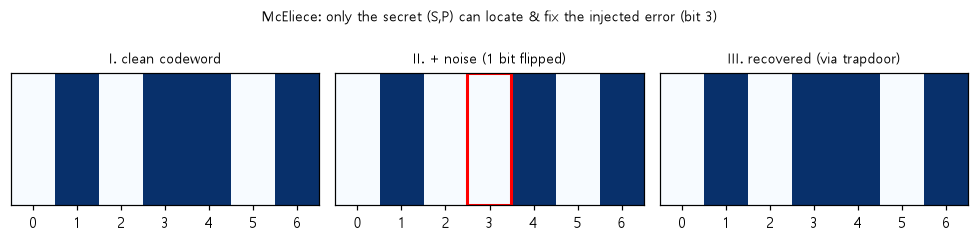

In [20]:
# 한 사례의 원본→노이즈→복원 단계를 비트로 시각화
Gpub, sk = mce_keygen(RNG)
m = np.array([1, 0, 1, 1])
clean = GF2(m @ Gpub)
ct = mce_encrypt(m, Gpub, RNG)
noise = GF2(ct - clean)
recovered = mce_decrypt(ct, sk)
fig, axes = plt.subplots(1, 3, figsize=(9, 2.2))
for ax, data, title in [(axes[0], clean, 'I. clean codeword'),
                        (axes[1], ct,    'II. + noise (1 bit flipped)'),
                        (axes[2], GF2(recovered @ Gpub), 'III. recovered (via trapdoor)')]:
    ax.imshow(data.reshape(1, -1), cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_title(title, fontsize=9); ax.set_yticks([]); ax.set_xticks(range(len(data)))
flip = int(np.where(noise)[0][0]) if noise.any() else -1
axes[1].add_patch(plt.Rectangle((flip-0.5, -0.5), 1, 1, fill=False, edgecolor='red', lw=2))
plt.suptitle(f'McEliece: only the secret (S,P) can locate & fix the injected error (bit {flip})', fontsize=9)
plt.tight_layout(); plt.show()

### 3-1. 그래프 해석

세 개의 패널은 각각 다음을 나타냅니다.

- **I (왼쪽)**: 오타가 없는 깨끗한 원문 상태(부호어)입니다.
- **II (가운데)**: 일부러 오타를 섞은 암호문. **빨간 네모**가 뒤집힌 오류 1비트의 위치입니다.
  이 상태로 전송되므로, 도청자가 보는 것도 이 그림입니다.
- **III (오른쪽)**: 비밀키 $(S, P)$ 로 복원한 결과. **왼쪽 패널과 완전히 같아진 것**이
  복원 성공의 증거입니다.

공개키만 가진 사람에게는 7칸 중 어느 칸이 오타인지 알 방법이 없지만,
비밀키 — 뒤섞인 표를 원래의 잘 정리된 교정표로 되돌리는 열쇠 — 를 가진 사람은
오타 위치를 정확히 찾아 고칩니다.
**"아는 사람만 고칠 수 있다"는 비대칭이 코드 기반 암호의 안전성 그 자체**입니다.

### 3-2. 실무 적용성

- **측정**: 비밀키가 있으면 복호 100%입니다. 공개키 $G'$ 만으로는 어느 비트가 오류인지
  특정할 수 없으며, 이 비대칭이 안전성의 근거입니다.
- **장점**: 계산이 단순한 표 곱하기라 **암호화·복호가 빠르고**, 1978년 이래
  **가장 오래 살아남은** 신뢰가 있습니다. NIST가 KEM 백업으로 Classic McEliece를 오래
  평가했고, 2025년에는 준순환 부호 기반 **HQC**를 추가 표준으로 선정했습니다.
- **치명적 단점**: **공개키가 큽니다.** Classic McEliece의 공개키는 수백 KB~1 MB 수준으로,
  사진 파일 하나만 한 크기입니다. HQC는 그보다 작지만 여전히 격자 계열보다 큽니다.
  따라서 통신 용량과 저장 공간이 넉넉하고 키를 자주 바꾸지 않는 환경
  (예: 서버 간 통신)에서 현실적입니다.
- **역할 분담**: 주력 KEM은 격자 기반(Kyber, ML-KEM)이고, 코드 기반은 격자 암호가 혹시
  깨질 경우를 대비한 **보험(백업)** 역할입니다. 서로 다른 수학 문제에 안전성을 걸어 두면
  하나가 무너져도 다른 하나가 버티기 때문입니다.

> **정리**: 코드 기반은 "일부러 넣은 오타를 비밀 교정기로 걷어내는" 방식으로,
> 오래 검증된 백업이지만 공개키가 큰 것이 약점입니다.

## 4. 연습문제

직접 코드를 고쳐 보면서 감을 잡아 보세요. 수학 없이 코드 몇 줄만 바꾸면 됩니다.

1. **오타 개수 실험**: `mce_encrypt` 에서 오류를 1비트가 아니라 **2비트** 넣도록
   바꿔 보세요(`e` 에 서로 다른 두 위치를 1로 설정). 2,000회 검증의 성공률이 어떻게
   변하나요? "Hamming(7,4)는 오타를 1개까지만 고칠 수 있다"는 사실과 연결해 설명해 보세요.

2. **오타가 없다면**: `mce_encrypt` 의 오류 삽입 줄을 없애(`e` 를 모두 0으로) 실행해 보세요.
   복호는 여전히 성공하지만, 암호로서는 무엇이 무너질까요? 오타가 없으면 공개키 $G'$ 만으로도
   누구나 원문 $m$ 을 되찾을 수 있는 이유를 생각해 보세요.
   (힌트: 일부러 넣은 오타야말로 이 암호의 자물쇠입니다.)

3. **반복 횟수와 신뢰도**: 검증 루프의 `T = 2000` 을 `20000` 으로 늘려도 성공률이
   1.000으로 유지되는지 확인하고, `timeit` 도우미로 1회 암호화·복호에 걸리는 시간을 재 보세요.

4. **뒤섞기 재료의 역할**: `mce_keygen` 에서 $S$ 를 "아무것도 섞지 않는 상태"(항등행렬,
   `S = np.eye(4, dtype=int)`)로 고정하면 복호는 성공하나요? 그렇다면 내용물 섞기($S$)와
   순서 바꾸기($P$)가 각각 보안에서 어떤 역할(교정표의 정체 숨기기)을 맡는지 정리해 보세요.

## 요약

- 코드 기반 암호는 **일부러 넣은 오타(오류)를 오류정정 코드로 걷어내는** 방식입니다.
  오타 교정 비법을 아는 쪽(비밀키 보유자)만 원문을 복호할 수 있습니다.
- 함정문 $G' = SGP$ 는 잘 정리된 교정표 $G$ 를 두 번 뒤섞어($S$: 내용물 섞기,
  $P$: 순서 바꾸기) 겉보기에 규칙 없는 공개키를 만드는 장치입니다.
- Hamming(7,4) 축소판 실험에서 비밀키 복호는 **2000/2000 (100%)** 성공했고,
  공개키만으로는 오류 비트 위치를 특정할 수 없었습니다.
- McEliece는 1978년 제안된 **가장 오래 검증된 PQC**이며, NIST는 2025년 준순환 부호 기반
  **HQC**를 백업 KEM 표준으로 추가 선정했습니다.
- 공개키가 큰 것(수백 KB~1 MB)이 약점이라, 주력은 격자 기반(Kyber)이고
  코드 기반은 수학적 가정을 분산하는 **백업(보험)** 역할을 맡습니다.

> 실제 Classic McEliece는 Goppa 부호와 훨씬 큰 파라미터를 사용하지만,
> "노이즈 삽입 → 함정문으로 정정"이라는 뼈대는 이 축소판과 동일합니다.